#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

Multimodal data noise typically includes mismatched image-text pairs, low-quality or blurry images, and irrelevant or machine-generated text like random web URLs instead of descriptive captions. These noisy elements negatively impact training by causing the model to learn spurious correlations and incorrect alignments between visual and textual concepts, which dilutes the robustness of the model. Examples of noisy data points include an image of a dog paired with the text click here to buy, or a heavily watermarked image paired with a generic description. To develop estimators capable of distinguishing between noisy and noise-free data, one can use pre-trained models to compute similarity scores between the image and text embeddings, filtering out pairs with low alignment scores as a candidate explanation for the success of data filtering techniques. If unlimited funding were available, the ideal way to clean the dataset would be to hire large teams of expert human annotators to manually verify, accurately caption, and strictly filter every image-text pair to ensure perfect relevance and safety without relying on the biases of automated systems.

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

The intuition behind utilizing frozen large language models as the backbone for multimodal tasks is that these models, when trained at a sufficient scale, already exhibit powerful few-shot learning capabilities and contain vast encyclopedic knowledge. By keeping the language model frozen and only training the vision components, this approach successfully transfers the few-shot learning ability to a multimodal setting without catastrophic forgetting. To facilitate the integration of diverse information, vision encoders are used to represent each image as a sequence of continuous embeddings. The frozen language models process and interpret this information by treating the sequence of continuous visual embeddings as a prefix or visual prompt, seamlessly attending to these visual tokens alongside traditional text embeddings to generate the appropriate textual completion.

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

To accurately identify and select the most impactful data for enhancing instruction tuning, we can utilize techniques like influence distillation and low-rank gradient similarity search, which estimate the influence of individual training datapoints using gradient information. This approach involves constructing a highly reusable gradient datastore with low-dimensional features and selecting training examples based on their gradient similarity to a few-shot validation set embodying a specific target capability. Given the complexity of diverse multimodal information, strategies to ensure effectiveness include tracking cross-modal alignment trajectories to find examples with similar cross-modal attention matrices, and clustering data to select subsets based on informativeness, uniqueness, and representativeness. By explicitly prioritizing data that minimizes the loss on a target task rather than relying on surface-level text or visual cues, practitioners can systematically filter out unhelpful or redundant data and construct a highly influential instruction-tuning dataset that maximizes the multimodal model's reasoning capabilities.

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

Besides watermarking, which can be limited in effectiveness, other methods to differentiate between AI-generated and human-created content include using AI detection classifiers trained to identify statistical anomalies, analyzing content for unnatural structural patterns like anatomical errors in images, detecting physical inconsistencies in videos, and implementing cryptographic provenance tracking to verify the origin of the media. However, as generative artificial intelligence technologies continue to rapidly develop and produce increasingly high-fidelity text, images, audio, and video, these detection methods are becoming less reliable. Consequently, distinguishing between human and synthetic content purely through post-hoc analysis is becoming virtually impossible, shifting the necessity toward proactive, embedded transparency measures and strict regulatory standards.

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?

I agree with the view that models like Sora do not truly understand the real world or underlying physical rules. Current video generation models operate by mapping complex statistical patterns from vast training data to simulate realistic imagery, which results in surface-level generalization rather than a causal prediction mechanism grounded in physical laws. The future development of generative AI systems can incorporate real-world knowledge, but achieving this likely requires moving beyond simple generative prediction toward architectures that learn from continuous sensory inputs, physical interaction, and joint embedding predictive architectures that model causal dynamics. Because current generative AI relies largely on interpolating past data rather than active physical deduction, pursuing purely generative AI is arguably not a viable or complete path towards achieving Artificial General Intelligence, which will necessitate continuous learning, true causal reasoning, and physical grounding.

# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [1]:
!pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA L4
SECRET_WORD: I LOVE MMAI


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
DRIVE_ROOT = "/content/drive/MyDrive"
DATA_DIR = os.path.join(DRIVE_ROOT, "data")  # ToolBench data (toolllama JSONs, processed)

print(f"Data (ToolBench): {DATA_DIR}")
print(f"Data exists: {os.path.isdir(DATA_DIR)}")


Data (ToolBench): /content/drive/MyDrive/data
Data exists: True


# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [5]:
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# Your zip should unpack into a folder called mmai-data/ with:
#   mmai-data/
#   ├── images/
#   │   ├── image_01.jpg
#   │   ├── ...
#   │   └── image_16.jpg
#   └── data.jsonl
#
# Each line in data.jsonl should be a JSON object with three
# fields: "image", "question", and "answer". For example:
#
#   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
#   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
#
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

import json
import sys
import os
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

# _REPO_ROOT = Path("/home/arthurdls/Documents/SP26/6.S985")  # local
_REPO_ROOT = Path("/content/drive/MyDrive")
sys.path.insert(0, str(_REPO_ROOT))
from api_card_renderer import render_one_example, truncate_text

# Load the processed dataset (produced by HW1)
df = pd.read_csv(os.path.join(DATA_DIR, "processed", "toolbench_modalities.csv"))
print(f"Loaded {len(df)} rows from toolbench_modalities.csv")

MMAI_ROOT = Path("/content/mmai-data")
MMAI_ROOT.mkdir(parents=True, exist_ok=True)
(MMAI_ROOT / "images").mkdir(exist_ok=True)

N_TRAIN = 800
N_TEST  = 200
RANDOM_STATE = 42

df_sub = df.sample(n=min(N_TRAIN + N_TEST, len(df)), random_state=RANDOM_STATE)
train_df, test_df = train_test_split(df_sub, test_size=N_TEST, random_state=RANDOM_STATE)


def build_jsonl(split_df, split_name):
    records = []
    for idx, (_, row) in enumerate(split_df.iterrows()):
        img_name = f"{split_name}_{idx:05d}.jpg"
        img_path = MMAI_ROOT / "images" / img_name
        render_one_example(row, out_path=img_path)

        # Vision input  = API list image
        # Language input = NL instruction
        # Language output = function calls used
        question = (
            f"Instruction: {row['instruction']}\n\n"
            "Given the available APIs shown in the image, which function calls should be made?"
        )
        answer = truncate_text(row["function_calls_used"], 300)
        records.append({
            "image":    f"images/{img_name}",
            "question": question,
            "answer":   answer,
        })
    return records


train_records = build_jsonl(train_df, "train")
test_records  = build_jsonl(test_df,  "test")

with open(MMAI_ROOT / "data.jsonl", "w") as f:
    for r in train_records + test_records:
        f.write(json.dumps(r) + "\n")

print(f"Saved {len(train_records)} train + {len(test_records)} test records.")
print(f"Example train record:\n{json.dumps(train_records[0], indent=2)[:400]}")

Loaded 20762 rows from toolbench_modalities.csv
Saved 800 train + 200 test records.
Example train record:
{
  "image": "images/train_00000.jpg",
  "question": "Instruction: Could you please convert 250 EUR to USD? I also need the latest exchange rates for EUR to GBP and USD to GBP. Additionally, provide me with the historical rates for EUR to GBP and USD to GBP between 2019-01-01 and 2019-01-02. Thank you!\nBegin!\n\nGiven the available APIs shown in the image, which function calls should be made?",
 


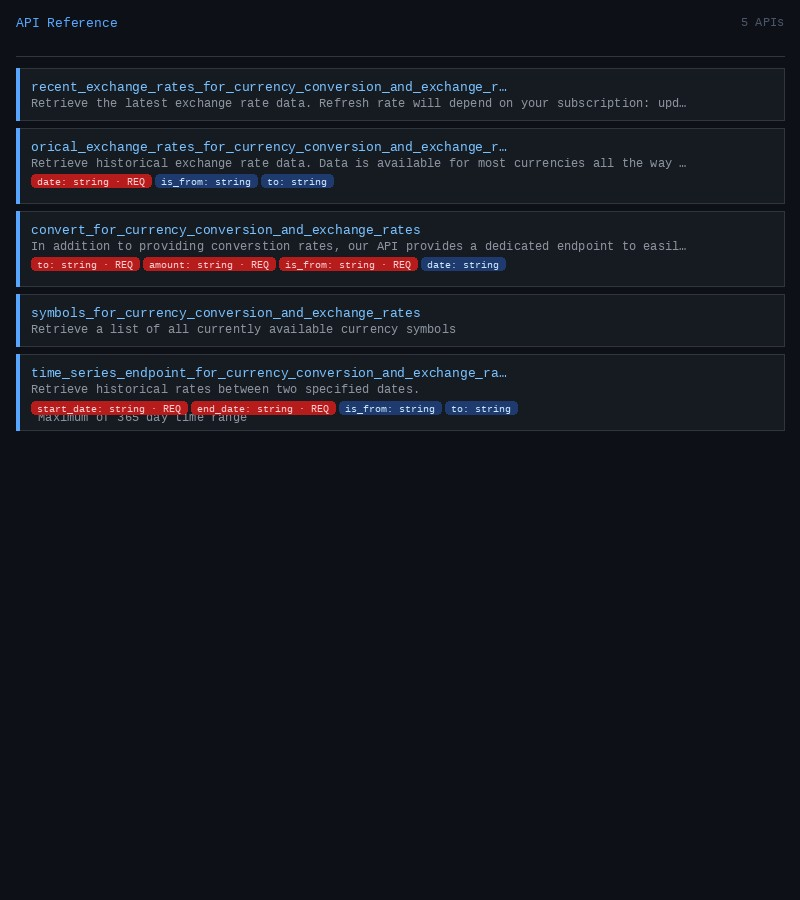

In [6]:
from PIL import Image
from IPython.display import display
img = Image.open(MMAI_ROOT / "images" / "train_00000.jpg")
display(img)

## Questions to Answer:

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).

* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?



**Answers**

- Converting non-image data (e.g., ToolBench API specs) into images can lose fine-grained information (exact numbers, raw text, structure that is easier to represent in JSON or text). The result also depends on rendering choices—layout, font size, resolution—so the same data can look different and affect model behavior. When squeezing complex data (e.g., many API cards) into one image, there can be clutter or ambiguity, and important detail may be lost when the image is later resized for the model.

- Visual representations are harder to parse programmatically than raw text or JSON. Performance is sensitive to resolution and cropping: if the model sees a downsampled or cropped image, it may miss critical details (e.g., small text on API cards).

- The code samples up to N_TRAIN + N_TEST (800 + 200) examples from the dataset with a fixed random_state=42, then uses train_test_split(..., test_size=N_TEST, random_state=RANDOM_STATE) to obtain 800 training and 200 test examples. I used a random split for simplicity and reproducibility. Alternatives considered could include stratifying by instruction type or by API set to ensure both splits cover similar variety, but the random split was chosen so that the split is repeatable and the test set is a straightforward random holdout.

# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [7]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Base (untrained) model and processor loaded successfully.

Test image 1 / 4: images/test_00000.jpg


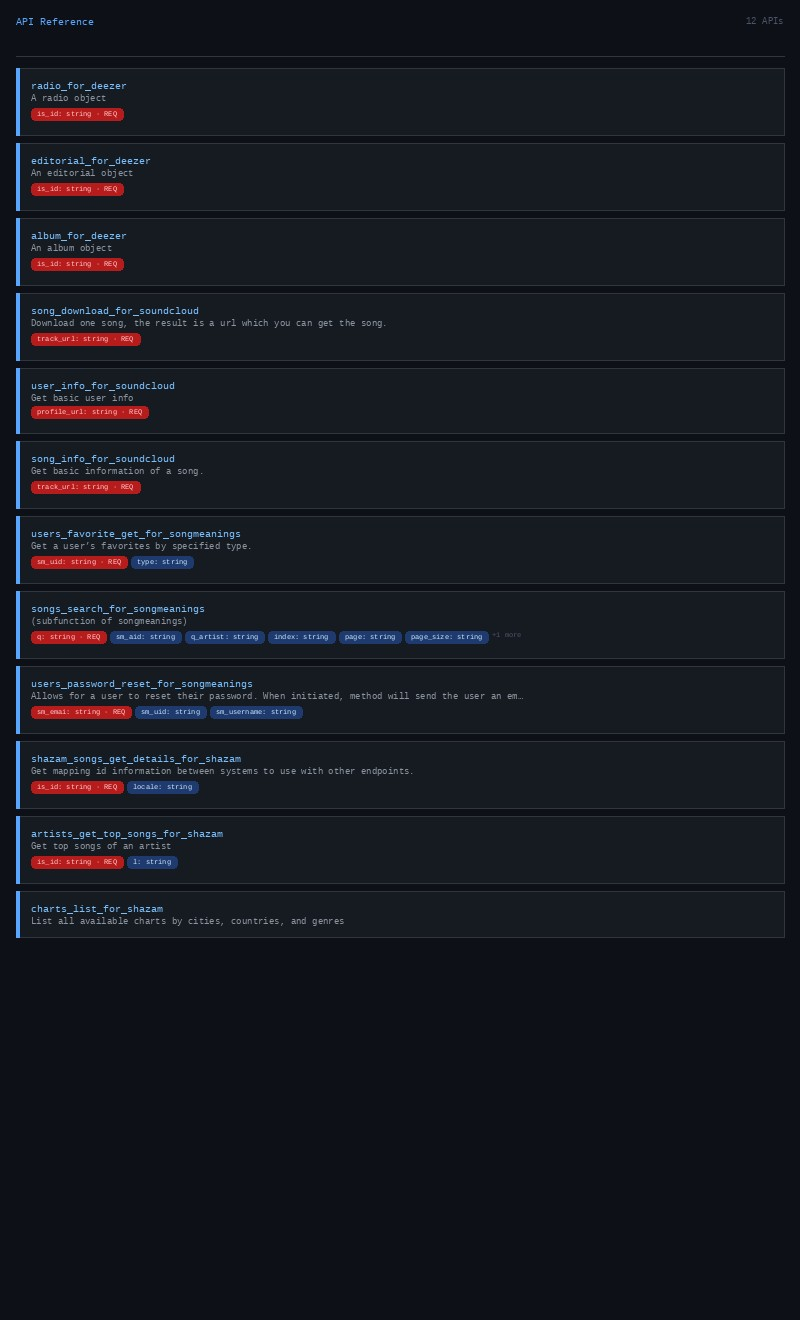


Question (prompt):
Instruction: I'm hosting a party and I need some upbeat songs to keep the energy high. Can you suggest some party anthems from different genres and provide the download links for each song? Additionally, I would like to know the basic information and lyrics of a specific song.
Begin!

Given the available APIs shown in the image, which function calls should be made?

Expected answer: charts_list_for_shazam|artists_get_top_songs_for_shazam|shazam_songs_get_details_for_shazam
Model answer:    system
You are an expert at reasoning about what function calls should be made to answer a question given a list of API calls. Add reasoning before the final output. Your only final output should be in the format of: first_api_name|second_api_name|third_api_name... (variable length depending on APIs needed)
user
Instruction: I'm hosting a party and I need some upbeat songs to keep the energy high. Can you suggest some party anthems from different genres and provide the download li

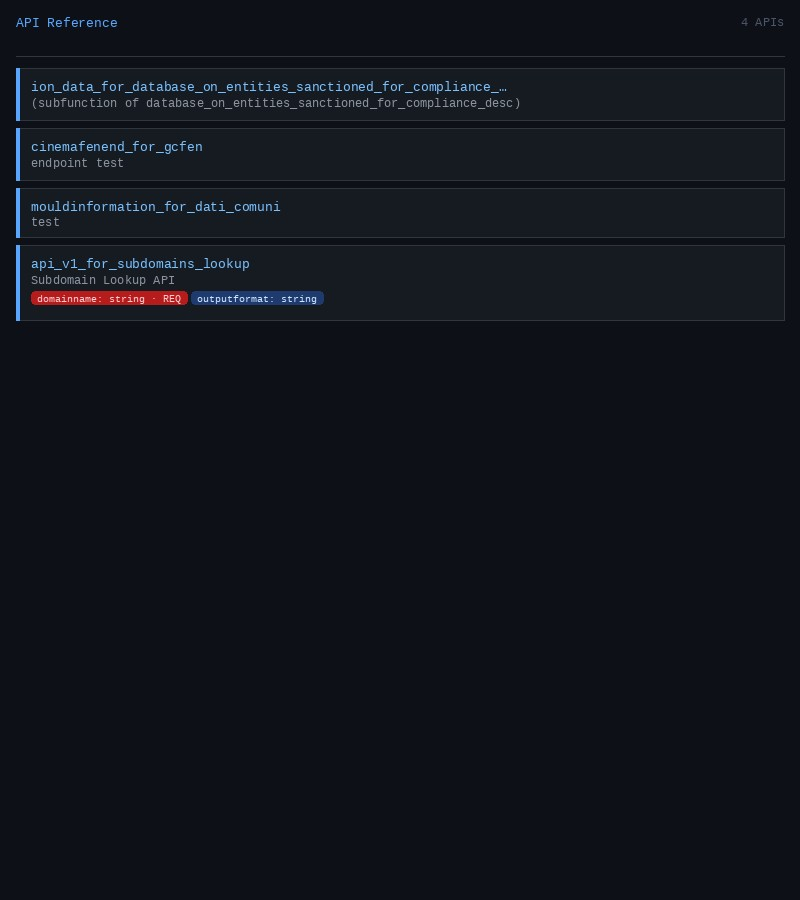


Question (prompt):
Instruction: I'm organizing a surprise birthday party for my sister and I need to find a good cinema in our city. Can you suggest a cinema and check if there are any sanctioned individuals or entities associated with it? Also, check for any subdomains related to the cinema's website.
Begin!

Given the available APIs shown in the image, which function calls should be made?

Expected answer: mouldinformation_for_dati_comuni|cinemafenend_for_gcfen|api_v1_for_subdomains_lookup|ion_data_for_database_on_entities_sanctioned_for_compliance_desc
Model answer:    system
You are an expert at reasoning about what function calls should be made to answer a question given a list of API calls. Add reasoning before the final output. Your only final output should be in the format of: first_api_name|second_api_name|third_api_name... (variable length depending on APIs needed)
user
Instruction: I'm organizing a surprise birthday party for my sister and I need to find a good cinema in ou

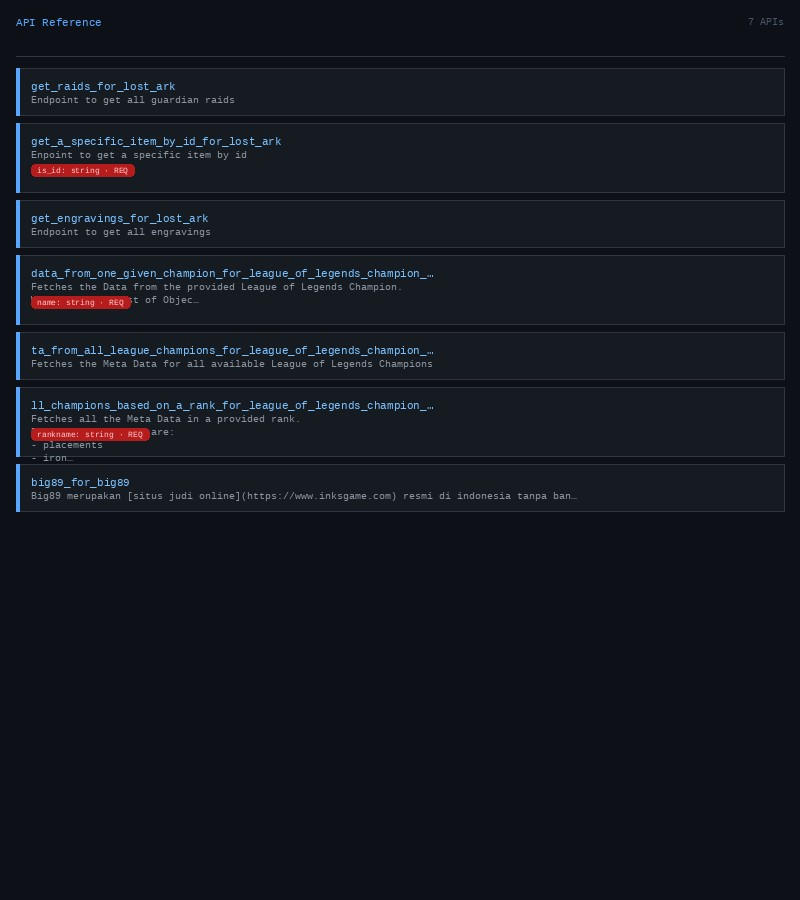


Question (prompt):
Instruction: I'm planning a trip to Lost Ark. Can you provide me with the details of all the available engravings? Additionally, fetch the information about the Brand champion from League of Legends Champion Meta API.
Begin!

Given the available APIs shown in the image, which function calls should be made?

Expected answer: get_engravings_for_lost_ark|data_from_one_given_champion_for_league_of_legends_champion_meta
Model answer:    system
You are an expert at reasoning about what function calls should be made to answer a question given a list of API calls. Add reasoning before the final output. Your only final output should be in the format of: first_api_name|second_api_name|third_api_name... (variable length depending on APIs needed)
user
Instruction: I'm planning a trip to Lost Ark. Can you provide me with the details of all the available engravings? Additionally, fetch the information about the Brand champion from League of Legends Champion Meta API.
Begin!

Give

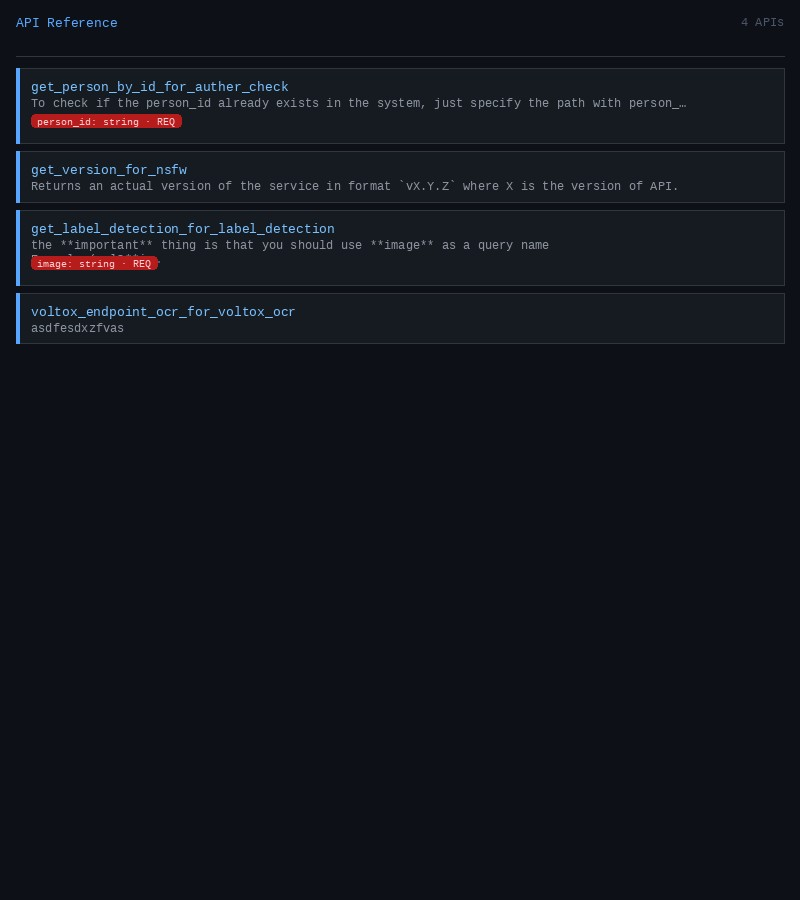


Question (prompt):
Instruction: I need to update my NSFW API to the latest version. Can you fetch the current version of the NSFW service for me? Also, I want to create an OCR tool that can extract text from images. Is there an OCR API available that I can integrate into my application?
Begin!

Given the available APIs shown in the image, which function calls should be made?

Expected answer: get_version_for_nsfw
Model answer:    system
You are an expert at reasoning about what function calls should be made to answer a question given a list of API calls. Add reasoning before the final output. Your only final output should be in the format of: first_api_name|second_api_name|third_api_name... (variable length depending on APIs needed)
user
Instruction: I need to update my NSFW API to the latest version. Can you fetch the current version of the NSFW service for me? Also, I want to create an OCR tool that can extract text from images. Is there an OCR API available that I can integrate int

In [9]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from PIL import Image, UnidentifiedImageError
from IPython.display import display
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
NUM_TEST_IMAGES: int = 4  # run baseline on first 4 held-out test images
# SYSTEM_PROMPT: str = "You are an expert at reasoning about what function calls should be made to answer a question given a list of API calls. Your only output should be in the format of: api_number_one|api_number_two|api_number_three..."
SYSTEM_PROMPT: str = "You are an expert at reasoning about what function calls should be made to answer a question given a list of API calls. Add reasoning before the final output. Your only final output should be in the format of: first_api_name|second_api_name|third_api_name... (variable length depending on APIs needed)"
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False           # set True for non-greedy decoding
TEMPERATURE: float = 0.7          # used only if DO_SAMPLE=True
TOP_P: float = 0.9                # used only if DO_SAMPLE=True
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False           # force CPU even if CUDA is available
DTYPE_IF_GPU = torch.bfloat16     # prefer bfloat16 on recent GPUs/Colab
DTYPE_IF_CPU = torch.float32

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    """Choose device/dtype and (optionally) a device_map for accelerate-style placement."""
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image_from_url(url: str) -> Image.Image:
    """Fetch image from URL and return a RGB PIL.Image with robust fallback."""
    url_str = str(url)
    if url_str.startswith("http"):
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        try:
            return Image.open(io.BytesIO(resp.content)).convert("RGB")
        except UnidentifiedImageError:
            # Fallback: write to disk then reopen (sometimes fixes truncated headers)
            tmp_path = "temp_image.jpg"
            with open(tmp_path, "wb") as f:
                f.write(resp.content)
            img = Image.open(tmp_path).convert("RGB")
            try:
                os.remove(tmp_path)
            except Exception:
                pass
            return img
    else:
        return Image.open(url).convert("RGB")


def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]


def main() -> None:
    device, torch_dtype, device_map = get_device_and_dtype()

    # 1) Load model + processor once (base, untrained)
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch_dtype,
        device_map=device_map,
    )
    print("Base (untrained) model and processor loaded successfully.\n")

    records = test_records[:NUM_TEST_IMAGES]
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    for i, rec in enumerate(records):
        image_path = MMAI_ROOT / rec["image"]
        question = rec["question"]
        expected = rec["answer"]

        print("=" * 60)
        print(f"Test image {i + 1} / {len(records)}: {rec['image']}")
        print("=" * 60)

        # Load and display image
        image = load_image_from_url(image_path)
        display(image)

        # Build chat, preprocess, generate
        messages = build_chat_messages(image, question)
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            gen_ids = model.generate(**inputs, **gen_kwargs)
        out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]

        print("\nQuestion (prompt):")
        print(question[:500] + ("..." if len(question) > 500 else ""))
        print("\nExpected answer:", expected)
        print("Model answer:   ", out)
        print()

    print("Done. Ran base (untrained) model on", len(records), "test images.")


if __name__ == "__main__":
    main()


**Reflection (5–8 sentences)**

- What worked: Asking for a structured output format (e.g., pipe-separated API names like api_one|api_two|...) improved consistency and made outputs easier to parse and compare to ground truth. When the prompt clearly specified the expected format, the model followed it more reliably.

- What failed: The default or unstructured prompt did not work well. When I asked the model to “add reasoning before the final output” while still requiring the structured format, it often did not truly reason—it just produced the structured answer. So I saw a tradeoff: either get more interpretable (but less structured) output, or get reliable format with little real reasoning.

- Patterns in mistakes: Errors tended to occur when the task was complex or when the output format was under-specified. The model did not always use the image content reliably; it sometimes seemed to rely on the question text or surface patterns. That suggests the model may not consistently ground its answer in the API card image when the prompt does not strongly constrain the format.

# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


**Reflection (Prompt Engineering)**

- Enforcing a structured output format (e.g., pipe-separated API names like first_api|second_api|...) improved consistency and parseability. The default or less structured prompt did not work as well; the model was more reliable when given an explicit format to follow.

- Adding structure (clear format instructions) helped the model produce consistent, parseable answers. Asking for “reasoning before the structured output” did not yield real reasoning—the model tended to output the structured answer without substantive reasoning, so there was a tradeoff: either get interpretable reasoning (with less reliable format) or get a reliable format (with little actual reasoning).

- Yes. The tension between “reason first” and “output in format X” was surprising: when instructed to reason and then give the structured output, the model still mostly satisfied the format and skipped real reasoning. So in practice we had to choose between interpretability (reasoning) and reliability (structured output), rather than getting both.

# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


In [11]:
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 30
LR: float        = 1e-5
BSZ_PER_DEV: int = 4
GRAD_ACCUM: int  = 4
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 384   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 800  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "/content/mmai-data/data.jsonl"
OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "List objects you see.",
            "answer": "cat, sofa, blanket, remote, cushion, tail, paw"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "List objects you see.",
            "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    # img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
# device_map = "auto" if use_cuda else None
device_map = "cuda:0" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",              # keep simple; eval loop optional
    save_strategy="steps",
    save_steps=10_000,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 800, longest_edge to 3200


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Step,Training Loss
1,6.199437
2,5.996358
3,6.011287
4,5.867167
5,6.127388
6,5.912156
7,6.004162
8,5.985502
9,5.760346
10,5.768471


Training complete. LoRA adapters saved to: /content/qwen2_5_vl_lora_fp16_t4


# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?



1. The settings reported here are those in the notebook’s CHANGE ME section (used as the “best” among the configurations tried): NUM_EPOCHS=30, LR=1e-5, BSZ_PER_DEV=4, GRAD_ACCUM=4, EVAL_SPLIT=0.1, SEED=42, MAX_SEQ_LEN=384, SHORTEST_EDGE=800. Other LoRA/sequence parameters in that cell were left at their defaults.

2. Learning rate (tried 1e-4 and 1e-5), number of epochs, and image resolution (tested up to 800 for the shortest edge) had the most noticeable effect. Batch size was also varied (from 64 down to 4×4 with gradient accumulation). Despite these changes, the model consistently overfit: validation behavior did not improve in a stable way, and the model often stopped using the image.

3. Across the settings tried, the model overfit to the extent that it frequently stopped using the image and relied on text or pattern memorization. A plausible reason is that after resizing/downsampling, the API card images contained enough noise or information loss that the visual signal was less reliable than the text in the question, so the model learned to ignore the image and match question patterns to answers. That would explain why changing learning rate, epochs, resolution, or batch size did not fix the issue: the bottleneck was the usefulness of the visual input and the small dataset size, not just the choice of hyperparameters.

# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [12]:

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    # device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


Image size: (800, 1320)
Image:


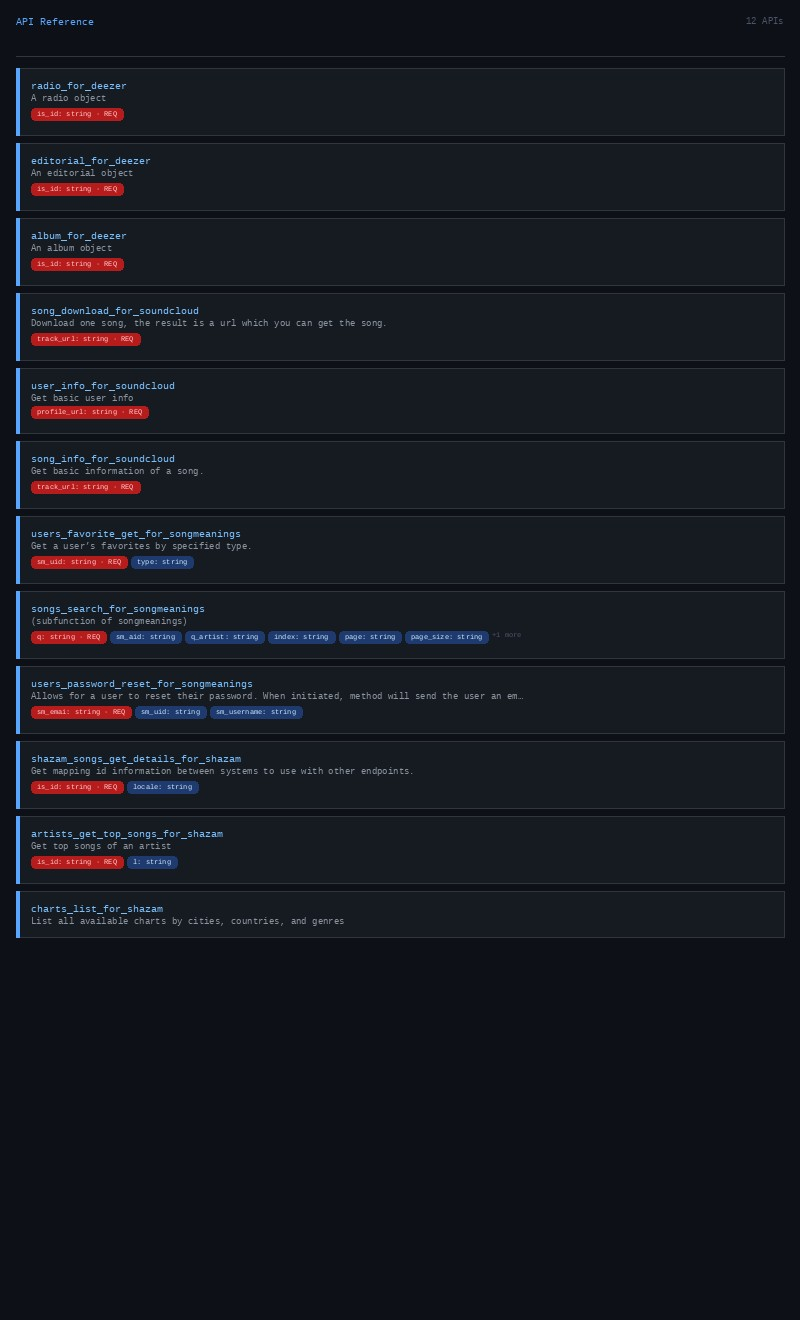

Model Output: system
You are a helpful assistant.
user
Instruction: I'm hosting a party and I need some upbeat songs to keep the energy high. Can you suggest some party anthems from different genres and provide the download links for each song? Additionally, I would like to know the basic information and lyrics of a specific song.
Begin!

Given the available APIs shown in the image, which function calls should be made?
assistant
get_party_anthems_for_party|get_song_info_and_lyrics_for_party_anthems
Expected Output: charts_list_for_shazam|artists_get_top_songs_for_shazam|shazam_songs_get_details_for_shazam


In [13]:
from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
first_test_image = MMAI_ROOT / test_records[0]["image"]
first_test_question = test_records[0]["question"]
TEST_IMAGE: str = first_test_image
TEST_QUESTION: str = first_test_question
EXPECTED_OUTPUT: str = test_records[0]["answer"]
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Load image
loaded_img = load_image_from_url(TEST_IMAGE)
print("Image size:", loaded_img.size)

# Display image
print("Image:")
display(loaded_img)

# Prepare messages
messages = [{"role": "user", "content": [
    {"type": "image", "image": loaded_img},
    {"type": "text", "text": TEST_QUESTION}
]}]

# Encode and generate
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(ft_model.device)

with torch.no_grad():
    out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

# Decode output
output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
print("Model Output:", output_text)
print("Expected Output:", EXPECTED_OUTPUT)


**Comparison: Pre-trained vs. fine-tuned on held-out images**

- Which questions showed improvement: In this setup, the pretrained model generally performed better on the held-out images. Fine-tuning did not consistently improve results; across the settings tried (learning rate, epochs, resolution, batch size), the fine-tuned model did not reliably do better than the baseline.

- Did LoRA fine-tuning correct any earlier mistakes: No. Instead of correcting mistakes, the fine-tuned model tended to overfit. It often ignored the API card image and produced answers that did not reflect the image content—likely relying on text or pattern memorization from the training set rather than reading the held-out image.

- Were any new errors or biases introduced after fine-tuning: Yes. Overfitting led to the model “making up” or pattern-matching answers instead of using the image. So for this task and dataset size, the pretrained model is the better choice; the fine-tuned model’s behavior (not using the image) is a clear regression. This suggests that with the current data size and visual complexity (e.g., resized API cards), the model found it easier to memorize text patterns than to rely on the visual signal.

# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

1. LoRA for parameter-efficient fine-tuning of vision-language models was the most interesting: training a small set of adapter weights while keeping the base model frozen makes it feasible to adapt a large VLM to a task-specific format (e.g., selecting API calls from an image) without full fine-tuning.

2. Understanding how VLMs can be adapted to task-specific output formats (e.g., structured API names from API card images) and where they fail—such as overfitting on small datasets or ignoring the image when the visual signal is noisy—is directly useful. It clarifies when fine-tuning helps versus when the pretrained model is sufficient, and how prompt design (e.g., structured output) interacts with model behavior.

3. Data efficiency and regularization for small-scale VLM fine-tuning would have been helpful: when and why fine-tuning hurts (e.g., overfitting so the model stops using the image), and how to evaluate whether the model is actually using the image versus memorizing text patterns. More on when to prefer the pretrained model over a fine-tuned one would also tie the assignment experience to the lectures.